In [15]:
import pandas as pd
from sklearn.metrics import r2_score

In [16]:
from sklearn.preprocessing import LabelEncoder
pr=pd.read_csv(r"/content/drive/MyDrive/Colab_Notebooks/datasets/Housing.csv")
enc=LabelEncoder()
pr["mainroad"]=enc.fit_transform(pr["mainroad"])
pr["mainroad"].unique()
pr["guestroom"]=enc.fit_transform(pr["guestroom"])
pr["guestroom"].unique()
pr["basement"]=enc.fit_transform(pr["basement"])
pr["basement"].unique()
pr["hotwaterheating"]=enc.fit_transform(pr["hotwaterheating"])
pr["hotwaterheating"].unique()
pr["airconditioning"]=enc.fit_transform(pr["airconditioning"])
pr["airconditioning"].unique()
pr["prefarea"]=enc.fit_transform(pr["prefarea"])
pr["prefarea"].unique()
pr["furnishingstatus"]=enc.fit_transform(pr["furnishingstatus"])
pr["furnishingstatus"].unique()
print(pr.to_string())
#pr.isnull().sum()

        price   area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  hotwaterheating  airconditioning  parking  prefarea  furnishingstatus
0    13300000   7420         4          2        3         1          0         0                0                1        2         1                 0
1    12250000   8960         4          4        4         1          0         0                0                1        3         0                 0
2    12250000   9960         3          2        2         1          0         1                0                0        2         1                 1
3    12215000   7500         4          2        2         1          0         1                0                1        3         1                 0
4    11410000   7420         4          1        2         1          1         1                0                1        2         0                 0
5    10850000   7500         3          3        1         1          0         1 

In [17]:
from sklearn.model_selection import train_test_split
x=pr[["area", "bedrooms", "bathrooms", "stories", "mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "parking", "prefarea", "furnishingstatus"]]
y=pr[["price"]]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(490, 12) (55, 12) (490, 1) (55, 1)


11410000: 7420, 4, 1, 2, 1 ,1, 1, 0, 1, 2, 0, 0

In [18]:
from sklearn import linear_model
rr=linear_model.Ridge(alpha=0.5)
rr.fit(x_train, y_train)
y_pred=rr.predict(x_test)
score_rr=r2_score(y_pred,y_test)
print(score_rr*100)
pred=rr.predict([[7420, 4, 1, 2, 1 ,1, 1, 0, 1, 2, 0, 0]])
print(pred)

42.37113694217264
[6716298.16037569]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


In [19]:
from sklearn import linear_model
lr=linear_model.Lasso(alpha=0.5)
lr.fit(x_train, y_train)
y_pred=lr.predict(x_test)
score_lr=r2_score(y_pred,y_test)
print(score_lr*100)
pred=lr.predict([[7420, 4, 1, 2, 1 ,1, 1, 0, 1, 2, 0, 0]])
print(pred)

42.70457983072535
[6714895.63088553]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


In [20]:

from sklearn import svm
svr=svm.SVR()
svr.fit(x_train, y_train)
y_pred=lr.predict(x_test)
score_svr=r2_score(y_pred,y_test)
print(score_svr*100)
pred=svr.predict([[7420, 4, 1, 2, 1 ,1, 1, 0, 1, 2, 0, 0]])
print(pred)

42.70457983072535
[4329546.385399]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Algorithms and their accuracy')

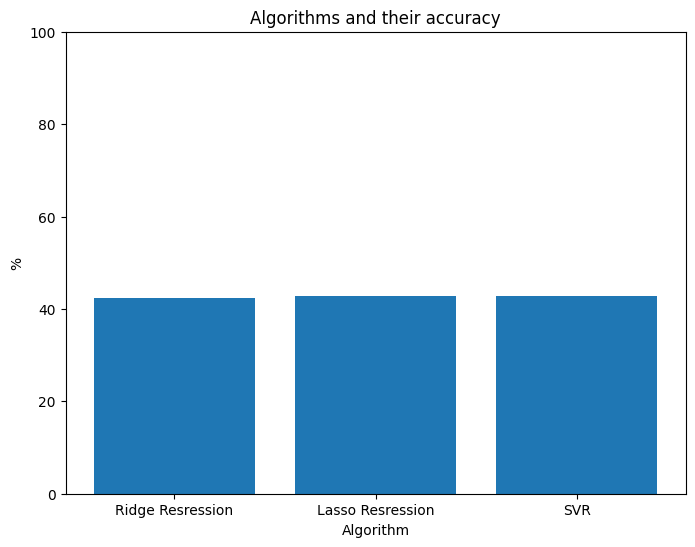

In [21]:


#Graph
import matplotlib.pyplot as plt

#x and y
x=['Ridge Resression', 'Lasso Resression', 'SVR']
y=[score_rr*100, score_lr*100, score_svr*100]

#plotting graph
plt.figure(figsize=(8,6))
plt.bar(x,y)
plt.xlabel('Algorithm')
plt.ylim(0,100)
plt.ylabel('%')
plt.title("Algorithms and their accuracy")